<a href="https://colab.research.google.com/github/divya-parmar5002/DivyaParmar/blob/Amdox_task_optimizer/Amdox_task_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Employee Input

In [49]:
import pandas as pd
def load_emotion_txt(file_path):
  data=[]
  with open(file_path,"r",encoding="utf-8")as f:
    for line in f:
        if not line.strip():
          continue
        text,emotion=line.strip().split(";",1)
        data.append([text.strip(),emotion.strip()])
  return pd.DataFrame(data,columns=["text","emotion"])

In [50]:
df_train=load_emotion_txt("/content/train.txt")
df_test=load_emotion_txt("/content/test.txt")
df_val=load_emotion_txt("/content/val.txt")

In [51]:
df=pd.concat([df_train,df_test,df_val],ignore_index=True)

In [52]:
print(df.shape)
print(df.head())

(20000, 2)
                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [53]:
df.to_csv("emotion_merged.csv",index=False)

In [54]:
final_df=pd.read_csv("/content/emotion_merged.csv")

In [55]:
final_df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [56]:
final_df.shape

(20000, 2)

In [57]:
print(final_df["emotion"].value_counts())

emotion
joy         6761
sadness     5797
anger       2709
fear        2373
love        1641
surprise     719
Name: count, dtype: int64


Data Preprocessing Layer

In [58]:
#Basic Text Cleaning
import re #regular expressions
def clean_text(text):
  text=text.lower() #lowercase
  text=re.sub(r'[^a-z\s]','',text) #remove punctuation/numbers
  text=re.sub(r'\s+',' ',text) #remove extra spaces
  return text.strip()

In [59]:
final_df["clean_txt"]=final_df["text"].apply(clean_text)

In [60]:
final_df.head()

,text,emotion,clean_txt
0,i didnt feel humiliated,sadness,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,anger,i am feeling grouchy


In [61]:
#Stopword Removal
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
def remove_stopwords(text):
    words=text.split()
    words=[w for w in words if w not in ENGLISH_STOP_WORDS]
    return " ".join(words)

In [62]:
final_df["clean_txt"]=final_df["clean_txt"].apply(remove_stopwords)

In [63]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
final_df["emotion_encoded"]=le.fit_transform(final_df["emotion"])

In [64]:
final_df["emotion_encoded"].head()


,emotion_encoded
0,4
1,4
2,0
3,3
4,0


In [65]:
final_df.columns

Index(['text', 'emotion', 'clean_txt', 'emotion_encoded'], dtype='object')

In [66]:
#Train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(final_df["clean_txt"],
                                               final_df["emotion_encoded"],
                                               test_size=0.2,
                                               random_state=42,
                                               stratify=final_df["emotion_encoded"])

In [67]:
model_df=final_df[["clean_txt","emotion_encoded"]]

In [68]:
model_df.head()

,clean_txt,emotion_encoded
0,didnt feel humiliated,4
1,feeling hopeless damned hopeful just cares awake,4
2,im grabbing minute post feel greedy wrong,0
3,feeling nostalgic fireplace know property,3
4,feeling grouchy,0


In [69]:
#TF-IDF Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)  # limit features to 5000 for efficiency

# Fit on training data and transform both train and test sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature shape:", X_train_tfidf.shape)

TF-IDF feature shape: (16000, 5000)


In [70]:
#model Training
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Initialize models
models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=500),
    "SVM": LinearSVC()
}

# Train models
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    print(f"{name} training completed.")

MultinomialNB training completed.
LogisticRegression training completed.
SVM training completed.



--- MultinomialNB Evaluation ---
Accuracy: 0.7525
Classification Report:
               precision    recall  f1-score   support

       anger       0.92      0.58      0.71       542
        fear       0.92      0.47      0.62       475
         joy       0.70      0.97      0.81      1352
        love       0.99      0.21      0.35       328
     sadness       0.74      0.93      0.82      1159
    surprise       1.00      0.07      0.13       144

    accuracy                           0.75      4000
   macro avg       0.88      0.54      0.58      4000
weighted avg       0.80      0.75      0.72      4000



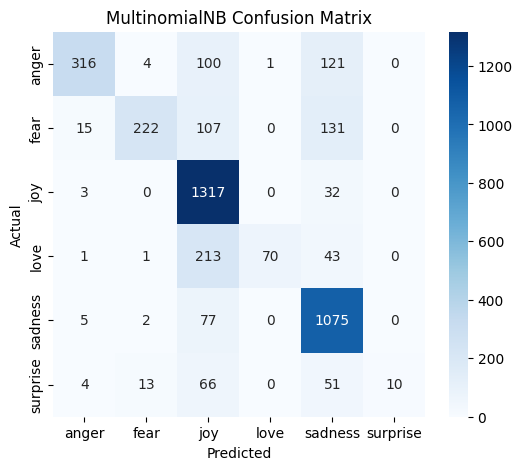


--- LogisticRegression Evaluation ---
Accuracy: 0.87575
Classification Report:
               precision    recall  f1-score   support

       anger       0.89      0.83      0.86       542
        fear       0.88      0.78      0.83       475
         joy       0.86      0.95      0.90      1352
        love       0.85      0.71      0.78       328
     sadness       0.90      0.92      0.91      1159
    surprise       0.90      0.61      0.73       144

    accuracy                           0.88      4000
   macro avg       0.88      0.80      0.83      4000
weighted avg       0.88      0.88      0.87      4000



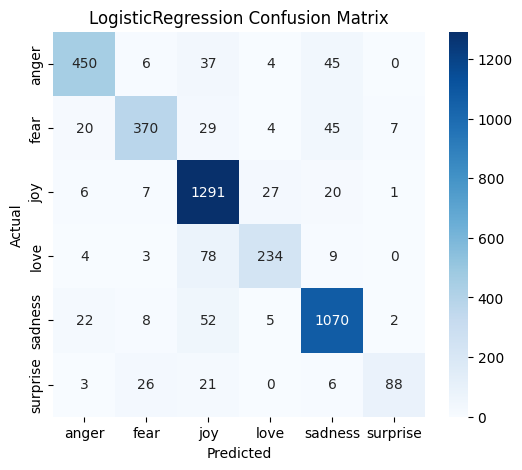


--- SVM Evaluation ---
Accuracy: 0.89025
Classification Report:
               precision    recall  f1-score   support

       anger       0.89      0.89      0.89       542
        fear       0.87      0.82      0.85       475
         joy       0.90      0.93      0.91      1352
        love       0.81      0.80      0.80       328
     sadness       0.92      0.92      0.92      1159
    surprise       0.83      0.76      0.80       144

    accuracy                           0.89      4000
   macro avg       0.87      0.85      0.86      4000
weighted avg       0.89      0.89      0.89      4000



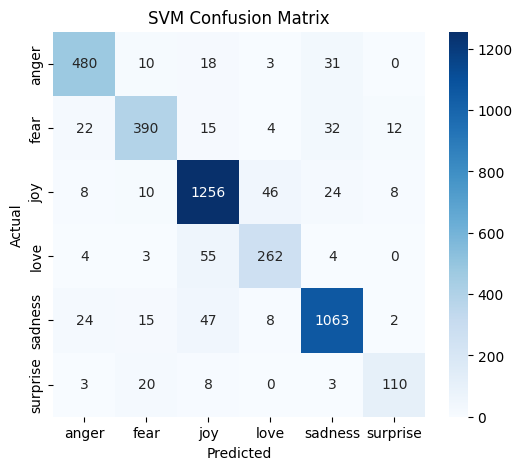

In [71]:
#Modal Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    print(f"\n--- {name} Evaluation ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [72]:
#Modal Comparison
model_scores = {}
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    model_scores[name] = accuracy_score(y_test, y_pred)

# Show comparison
print("Model Accuracy Comparison:")
for model, score in model_scores.items():
    print(f"{model}: {score:.4f}")

Model Accuracy Comparison:
MultinomialNB: 0.7525
LogisticRegression: 0.8758
SVM: 0.8902


In [73]:
#Making Predictions on New Text
def predict_emotion(text, model=models['LogisticRegression']):
    text_clean = clean_text(text)
    text_clean = remove_stopwords(text_clean)
    vector = tfidf.transform([text_clean])
    pred = model.predict(vector)[0]
    return le.inverse_transform([pred])[0]

# Example
sample_text = "I am so excited for today!"
predicted_emotion = predict_emotion(sample_text)
print(f"Text: '{sample_text}'\nPredicted Emotion: {predicted_emotion}")

Text: 'I am so excited for today!'
Predicted Emotion: joy


In [74]:
#Save Model and TF-IDF
import joblib

# Save model
joblib.dump(models['LogisticRegression'], 'emotion_model.pkl')

# Save TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Save LabelEncoder
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']